#  Decision Tree Classification on Iris Dataset

##  Project Overview
This project demonstrates how to build a **Decision Tree Classifier** to predict the species of flowers using the famous Iris dataset.

---

##  Objectives
- Train a Decision Tree model on labeled data
- Visualize the decision tree
- Apply pruning to avoid overfitting
- Evaluate model performance using metrics
- Interpret feature importance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Check Missing Values

In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

## EDA

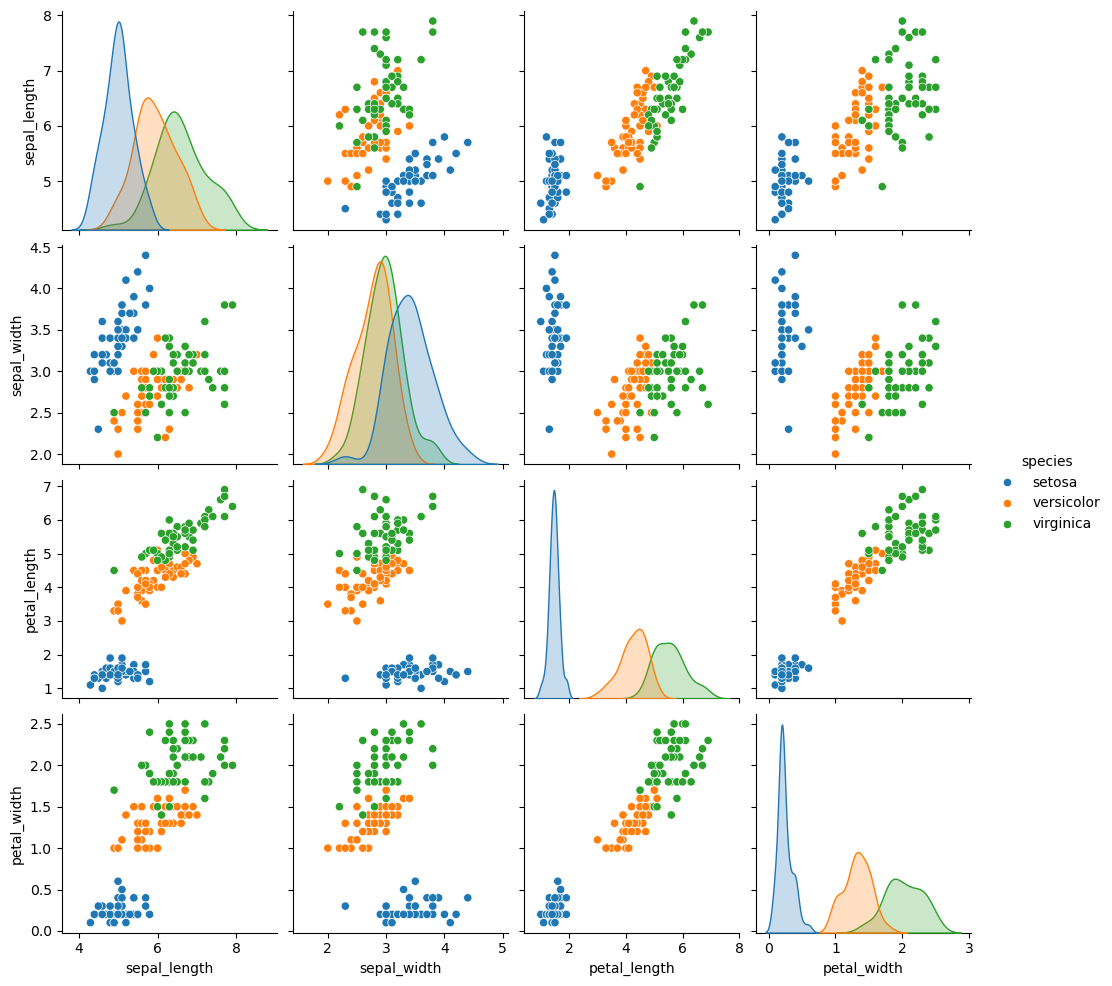

In [5]:
sns.pairplot(df, hue='species')
plt.show()

## Feature & Target Split

In [6]:
X = df.drop('species', axis=1)
y = df['species']

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Basic Decision Tree

In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Predictions & Accuracy

In [9]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Confusion Matrix

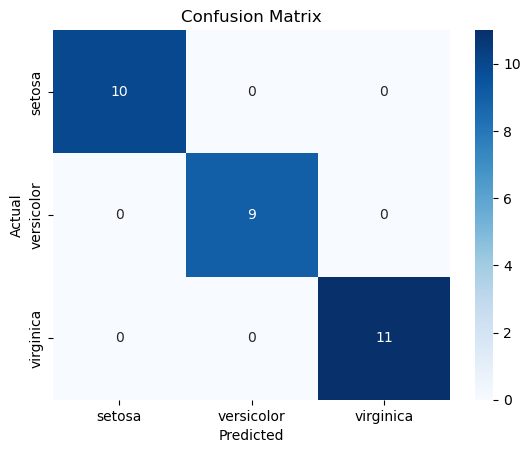

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(),
            yticklabels=y.unique())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Decision Tree Visualization

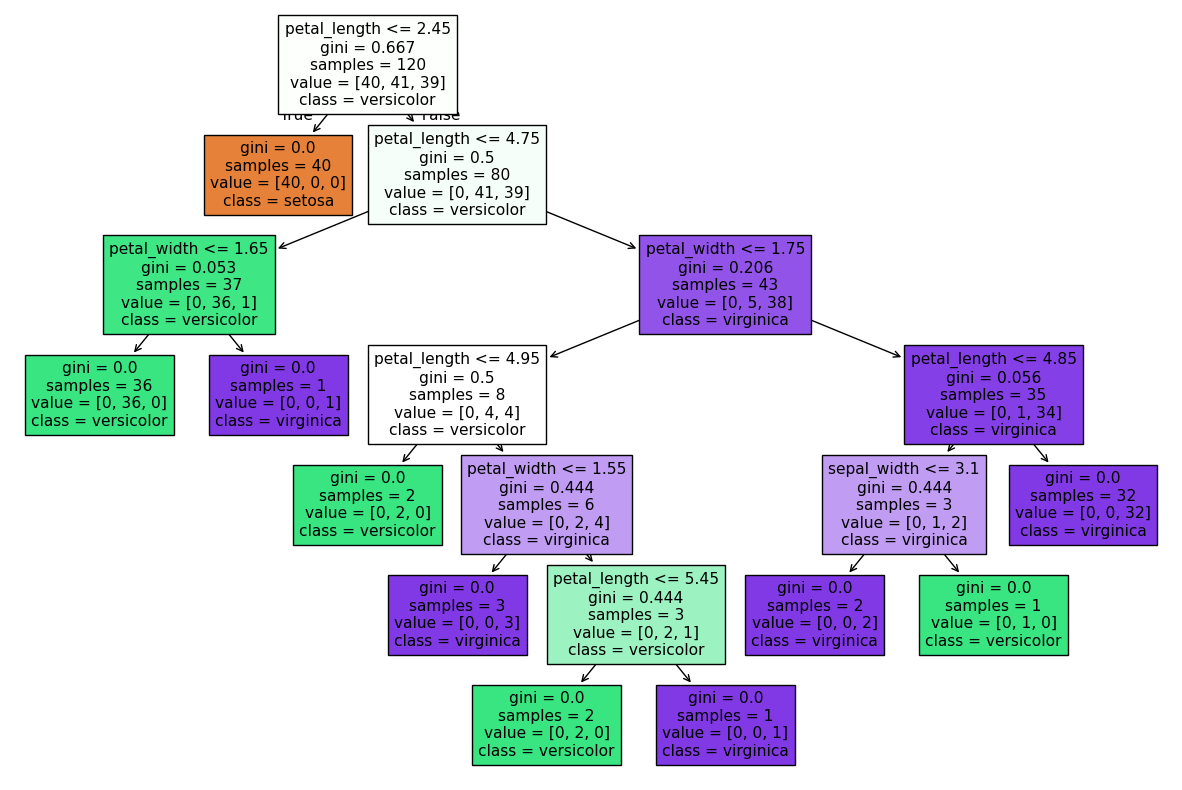

In [11]:
plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.show()

## Feature Importance

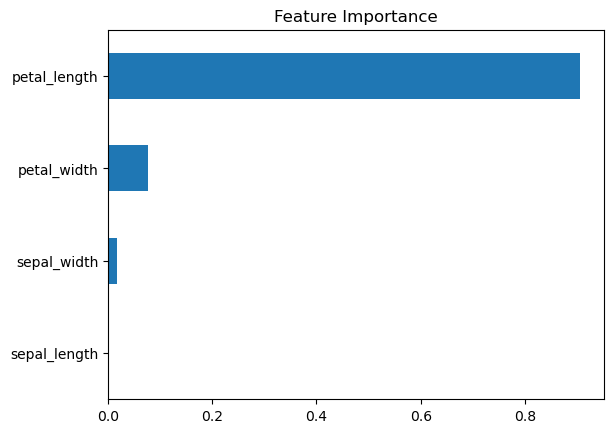

In [12]:
importance = pd.Series(dt.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## Hyperparameter Tuning

In [13]:
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}


## Train Optimized Model

In [14]:
best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Optimized Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Pruned Tree Visualization

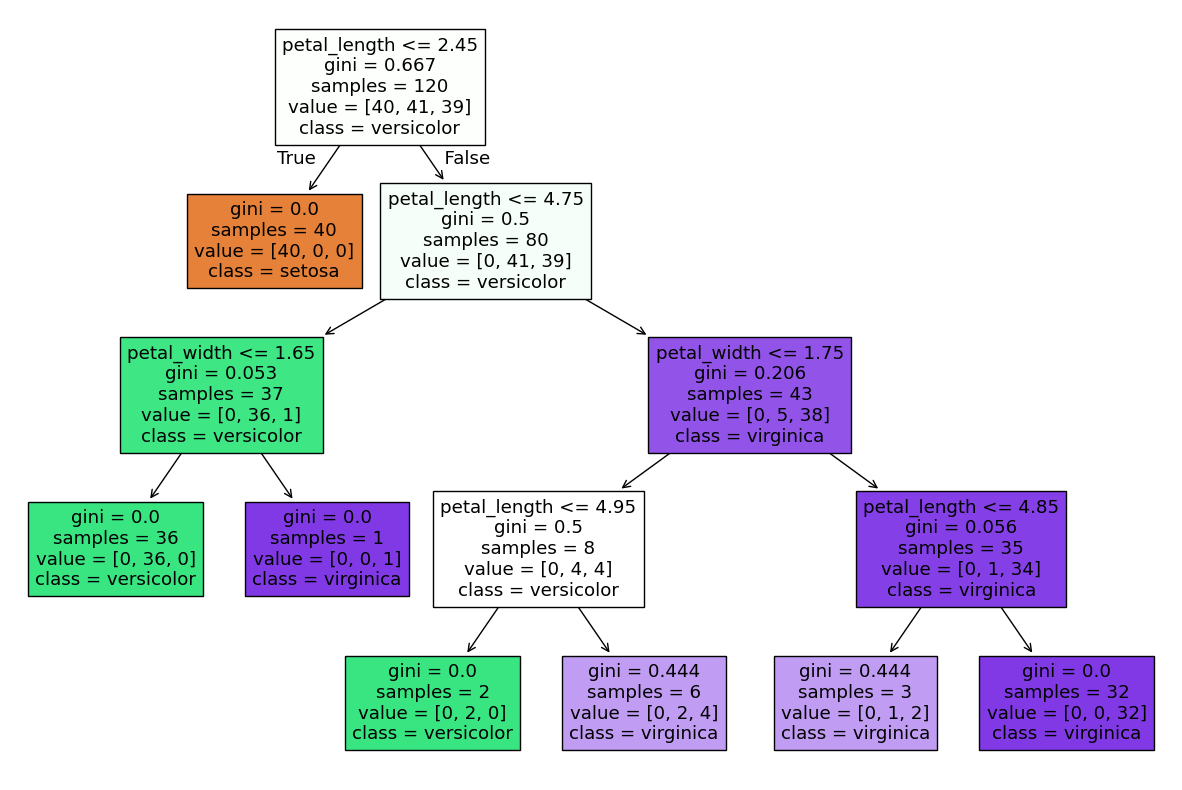

In [15]:
plt.figure(figsize=(15,10))
plot_tree(best_dt, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.show()

## Before vs After

In [16]:
print("Before Tuning Accuracy:", accuracy_score(y_test, y_pred))
print("After Tuning Accuracy:", accuracy_score(y_test, y_pred_best))

Before Tuning Accuracy: 1.0
After Tuning Accuracy: 1.0


##  Key Insights

- Decision Trees are highly interpretable models.
- Feature importance shows which features influence predictions the most.
- Pruning helps reduce overfitting and improves generalization.
- Hyperparameter tuning significantly enhances performance.

---

##  Conclusion

This project successfully demonstrates:
1. Model training  
2. Visualization  
3. Pruning  
4. Evaluation  
